<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>


</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>


# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from math import factorial
from scipy import stats as st



## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
df_calls = pd.read_csv('/datasets/megaline_calls.csv')
df_internet = pd.read_csv('/datasets/megaline_internet.csv')
df_messages = pd.read_csv('/datasets/megaline_messages.csv')
df_plans = pd.read_csv('/datasets/megaline_plans.csv')
df_users = pd.read_csv('/datasets/megaline_users.csv')



## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
df_plans.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
df_plans.sample(2)



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
1,1000,30720,3000,70,7,0.01,0.01,ultimate
0,50,15360,500,20,10,0.03,0.03,surf


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

En este caso a la hora de aplicar la informacion de el datasets se logra apreciar que las columnas no presentan codigos nulos, de igual manera no se logran detectar lineas duplicadas, es decir al parecer este datasets se encuentra en la forma correcta, y no es necesario examinarlo.

## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

## Usuarios/as

In [5]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [6]:
# Imprime una muestra de datos para usuarios
df_users.sample(10)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
452,1452,Miguel,Sparks,32,"Tucson, AZ MSA",2018-12-29,surf,NaN
414,1414,Georgianne,Herring,30,"Urban Honolulu, HI MSA",2018-03-03,surf,2018-09-01
201,1201,Jeanelle,Estrada,61,"Bridgeport-Stamford-Norwalk, CT MSA",2018-06-04,surf,NaN
155,1155,Claude,Hahn,19,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",2018-02-21,ultimate,NaN
351,1351,Kyle,Grimes,47,"San Antonio-New Braunfels, TX MSA",2018-09-05,ultimate,NaN
243,1243,Isaias,Compton,71,"Phoenix-Mesa-Chandler, AZ MSA",2018-05-11,surf,NaN
356,1356,Hae,Ryan,46,"Milwaukee-Waukesha, WI MSA",2018-05-16,surf,NaN
150,1150,Earlie,Giles,46,"Houston-The Woodlands-Sugar Land, TX MSA",2018-09-19,ultimate,NaN
348,1348,Carl,Rutledge,60,"Detroit-Warren-Dearborn, MI MSA",2018-10-05,surf,NaN
427,1427,Zofia,Brock,64,"Washington-Arlington-Alexandria, DC-VA-MD-WV MSA",2018-01-26,ultimate,NaN



[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Data la informacion de este datasets se logran encontrar algunos inconvenientes, como por el ejemplo se logran apreciar datos nulos en la columna: 'churn_date'.Asi mismo se logran observar tipos de datos erroneos, es decir tipos de datos de tipo string cuando en realidad son de tipo numerico. Dados los pequeños inconvenientes se procede a abordarlos de la mejor manera con el codigo necesario para hacer la transformacion.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [7]:
df_users['user_id'].astype('category')
df_users['reg_date']=pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d')
df_users.fillna({'churn_date':'unknown'}, inplace=True)
df_users['churn_date']=pd.to_datetime(df_users['churn_date'], format='%Y-%m-%d', errors='coerce')
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [8]:
df_users['reg_year'] = df_users['reg_date'].dt.year
df_users['reg_month'] = df_users['reg_date'].dt.month
df_users['reg_day'] = df_users['reg_date'].dt.day
df_users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,reg_month,reg_day
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,2018,12,24
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018,8,13
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,2018,10,21
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,2018,1,28
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,2018,5,23
...,...,...,...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaT,2018,9,4
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaT,2018,2,20
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaT,2018,12,10
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaT,2018,2,4


## Llamadas

In [9]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
df_calls.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [10]:
# Imprime una muestra de datos para las llamadas
df_calls.sample(10)


,id,user_id,call_date,duration
60931,1220_310,1220,2018-06-13,5.80
103526,1365_722,1365,2018-08-30,7.10
128574,1461_237,1461,2018-11-14,7.19
4225,1017_195,1017,2018-12-23,0.00
75859,1268_363,1268,2018-09-25,9.60
65481,1237_88,1237,2018-12-21,2.91
103226,1365_422,1365,2018-12-23,0.20
48876,1175_741,1175,2018-11-27,3.07
1658,1009_80,1009,2018-06-29,3.80
10550,1046_416,1046,2018-10-13,12.02


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Dada la informacion de este Datasets se logran observar ciertos inconvenientes, como dos pequeños errores en las columnas, 'user_id' y 'call_date', los tipos de datos se muestran de una forma erronea. En este caso se procede a convertir los datos, de esta forma la columna, 'user_id' paso de entero a de tipo string(object), la columna 'call_date' que era de tipo string(object) se convirtio en tipo numerico.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [11]:
df_calls['user_id'].astype('category')
df_calls['call_date']=pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [12]:
df_calls['year'] = df_calls['call_date'].dt.year
df_calls['month'] = df_calls['call_date'].dt.month
df_calls['day'] = df_calls['call_date'].dt.day
df_calls.head()

,id,user_id,call_date,duration,year,month,day
0,1000_93,1000,2018-12-27,8.52,2018,12,27
1,1000_145,1000,2018-12-27,13.66,2018,12,27
2,1000_247,1000,2018-12-27,14.48,2018,12,27
3,1000_309,1000,2018-12-28,5.76,2018,12,28
4,1000_380,1000,2018-12-30,4.22,2018,12,30


## Mensajes

In [13]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
df_messages.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [14]:
# Imprime una muestra de datos para los mensajes
df_messages.sample(10)



,id,user_id,message_date
357,1004_1,1004,2018-12-21
68117,1439_511,1439,2018-10-12
20483,1130_158,1130,2018-12-01
14230,1098_243,1098,2018-08-31
10388,1076_878,1076,2018-08-01
75335,1491_131,1491,2018-10-04
56973,1362_38,1362,2018-03-08
5426,1052_183,1052,2018-11-29
33486,1211_162,1211,2018-11-11
8172,1061_178,1061,2018-04-27


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Con respecto a la informacion de este datasets se logran observar inconvenientes similares al datasets anterior, se procede a abordarlos de la misma manera, conviertiendo asi dichas columnas. En este caso las columnas 'user_id' y 'message_date' son las que presentan ciertos errores.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [15]:
df_messages['user_id'].astype('category')
df_messages['message_date']=pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [16]:
df_messages['year'] = df_messages['message_date'].dt.year
df_messages['month'] = df_messages['message_date'].dt.month
df_messages['day'] = df_messages['message_date'].dt.day
df_messages.head()

,id,user_id,message_date,year,month,day
0,1000_125,1000,2018-12-27,2018,12,27
1,1000_160,1000,2018-12-31,2018,12,31
2,1000_223,1000,2018-12-31,2018,12,31
3,1000_251,1000,2018-12-27,2018,12,27
4,1000_255,1000,2018-12-26,2018,12,26


## Internet

In [17]:
# Imprime la información general/resumida sobre el DataFrame de internet
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [18]:
# Imprime una muestra de datos para el tráfico de internet
df_internet.sample(10)



,id,user_id,session_date,mb_used
101010,1478_161,1478,2018-11-15,308.47
40664,1182_399,1182,2018-06-30,36.18
50350,1224_180,1224,2018-09-04,899.20
55172,1250_36,1250,2018-10-15,757.46
9815,1050_235,1050,2018-05-23,417.23
72664,1338_60,1338,2018-10-06,135.01
28995,1132_467,1132,2018-07-30,620.57
88153,1406_470,1406,2018-05-26,543.79
748,1004_411,1004,2018-12-13,327.82
42782,1190_10,1190,2018-12-18,112.30


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Con respecto a la informacion de este datasets se logran observar los mismos inconvenientes que hemos visto en los datasets anteriores, es decir el mismo problema en las columnas. De inmediado se procede a trabajar en ellas, dando asi la necesidad de convertir cada una de ellas, las columnas que se trabajaron fueron 'user_id' y 'session_date'.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [19]:
df_internet['user_id'].astype('category')
df_internet['session_date']=pd.to_datetime(df_internet['session_date'], format= '%Y-%m-%d')
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [20]:
df_internet['year'] = df_internet['session_date'].dt.year
df_internet['month'] = df_internet['session_date'].dt.month
df_internet['day'] = df_internet['session_date'].dt.day
df_internet.head()

,id,user_id,session_date,mb_used,year,month,day
0,1000_13,1000,2018-12-29,89.86,2018,12,29
1,1000_204,1000,2018-12-31,0.00,2018,12,31
2,1000_379,1000,2018-12-28,660.40,2018,12,28
3,1000_413,1000,2018-12-26,270.99,2018,12,26
4,1000_442,1000,2018-12-27,880.22,2018,12,27


## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [21]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
df_plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [22]:
df_calls.head()

,id,user_id,call_date,duration,year,month,day
0,1000_93,1000,2018-12-27,8.52,2018,12,27
1,1000_145,1000,2018-12-27,13.66,2018,12,27
2,1000_247,1000,2018-12-27,14.48,2018,12,27
3,1000_309,1000,2018-12-28,5.76,2018,12,28
4,1000_380,1000,2018-12-30,4.22,2018,12,30


In [25]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado
monthly_calls = df_calls.groupby(['user_id', 'month']).size().reset_index(name='call_count')
print(monthly_calls.head())

   user_id  month  call_count
0     1000     12          16
1     1001      8          27
2     1001      9          49
3     1001     10          65
4     1001     11          64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Corregido!<br/>


</div>


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Cuidado!<br/>

La manera en la que haces la agrupación hace que sea difícil de trabajar después, ya que pierdes los nombres de las columnas, te dejo un ejemplo en la celda de abajo de como se puede realizar la agrupación que te puede servir para ejercicios más adelante
</div>


In [26]:
# Código del revisor
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

# Agrupar por usuario y mes, y contar llamadas
monthly_calls = df_calls.groupby(['user_id', 'month']).size().reset_index(name='call_count')

# Ver una muestra del resultado
print(monthly_calls.head())


   user_id  month  call_count
0     1000     12          16
1     1001      8          27
2     1001      9          49
3     1001     10          65
4     1001     11          64


In [27]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutesPerUser = df_calls.groupby(['user_id', 'month'])['duration'].sum().reset_index(name= 'duration_minus')
                        
minutesPerUser


,user_id,month,duration_minus
0,1000,12,116.83
1,1001,8,171.14
2,1001,9,297.69
3,1001,10,374.11
4,1001,11,404.59
...,...,...,...
2253,1498,12,324.77
2254,1499,9,330.37
2255,1499,10,363.28
2256,1499,11,288.56


In [28]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messagesPerUser=df_messages.groupby(['user_id' , 'month'])['id'].count().reset_index(name='mess_amnt')

messagesPerUser


,user_id,month,mess_amnt
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
...,...,...,...
1801,1496,9,21
1802,1496,10,18
1803,1496,11,13
1804,1496,12,11


In [29]:
messagesPerUser

,user_id,month,mess_amnt
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
...,...,...,...
1801,1496,9,21
1802,1496,10,18
1803,1496,11,13
1804,1496,12,11


In [30]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
volumenPerUser=df_internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
volumenPerUser.name='vol_sum'
volumenPerUser


,user_id,month,mb_used
0,1000,12,1901.47
1,1001,8,6919.15
2,1001,9,13314.82
3,1001,10,22330.49
4,1001,11,18504.30
...,...,...,...
2272,1498,12,23137.69
2273,1499,9,12984.76
2274,1499,10,19492.43
2275,1499,11,16813.83


[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [31]:

# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y mont


In [32]:
merged_df = pd.merge(monthly_calls, messagesPerUser, on=['user_id', 'month'], how='left')
merged_df = pd.merge(merged_df, minutesPerUser, on=['user_id', 'month'], how='left')
merged_df = pd.merge(merged_df, volumenPerUser, on=['user_id', 'month'], how='left')
merged_df['mess_amnt'] = merged_df['mess_amnt'].fillna(0)
merged_df 

,user_id,month,call_count,mess_amnt,duration_minus,mb_used
0,1000,12,16,11.0,116.83,1901.47
1,1001,8,27,30.0,171.14,6919.15
2,1001,9,49,44.0,297.69,13314.82
3,1001,10,65,53.0,374.11,22330.49
4,1001,11,64,36.0,404.59,18504.30
...,...,...,...,...,...,...
2253,1498,12,39,0.0,324.77,23137.69
2254,1499,9,41,0.0,330.37,12984.76
2255,1499,10,53,0.0,363.28,19492.43
2256,1499,11,45,0.0,288.56,16813.83


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Corregido!<br/>


</div>


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Cuidado!<br/>

La función no esta haciendo su trabajo correctamente porque los dataframes que se le han pasado no tienen las columnas mencionadas `month` `user_id` ya que estas columnas se perdieron en pasos anteriores
</div>


In [33]:
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,reg_month,reg_day
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,2018,12,24
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018,8,13
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,2018,10,21
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,2018,1,28
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,2018,5,23


In [34]:
df_plans.columns, df_users.columns

(Index(['messages_included', 'mb_per_month_included', 'minutes_included',
        'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute',
        'plan_name'],
       dtype='object'),
 Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
        'churn_date', 'reg_year', 'reg_month', 'reg_day'],
       dtype='object'))

In [35]:
merged_df

,user_id,month,call_count,mess_amnt,duration_minus,mb_used
0,1000,12,16,11.0,116.83,1901.47
1,1001,8,27,30.0,171.14,6919.15
2,1001,9,49,44.0,297.69,13314.82
3,1001,10,65,53.0,374.11,22330.49
4,1001,11,64,36.0,404.59,18504.30
...,...,...,...,...,...,...
2253,1498,12,39,0.0,324.77,23137.69
2254,1499,9,41,0.0,330.37,12984.76
2255,1499,10,53,0.0,363.28,19492.43
2256,1499,11,45,0.0,288.56,16813.83


In [36]:
# Añade la información de la tarifa
merged_df = pd.merge(merged_df, df_users[['user_id', 'plan']], on='user_id', how='left')
merged_df = merged_df.reset_index(drop=True)
merged_df


,user_id,month,call_count,mess_amnt,duration_minus,mb_used,plan
0,1000,12,16,11.0,116.83,1901.47,ultimate
1,1001,8,27,30.0,171.14,6919.15,surf
2,1001,9,49,44.0,297.69,13314.82,surf
3,1001,10,65,53.0,374.11,22330.49,surf
4,1001,11,64,36.0,404.59,18504.30,surf
...,...,...,...,...,...,...,...
2253,1498,12,39,0.0,324.77,23137.69,surf
2254,1499,9,41,0.0,330.37,12984.76,surf
2255,1499,10,53,0.0,363.28,19492.43,surf
2256,1499,11,45,0.0,288.56,16813.83,surf


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [37]:
# Calcula el ingreso mensual para cada usuario
def ingreso_mensual(row):
    if row['plan']== 'ultimate':
        ingreso=70
        if row['mess_amnt'] > 1000:
            ingreso=ingreso +(row['mess_amnt'] -1000)*0.01
        if row['call_count'] > 3000:
            ingreso=ingreso +(row['call_count'] -3000)*0.01
        if row['mb_used'] > 30000:
            ingreso=ingreso +(row['mb_used'] -30000)*0.007
        row['ingreso']=ingreso    
            
    if row['plan']=='surf':
        ingreso=20
        if row['mess_amnt'] > 50:
            ingreso=ingreso +(row['mess_amnt'] -50)*0.03
        if row['call_count'] > 500:
            ingreso=ingreso +(row['call_count'] -500)*0.03
        if row['mb_used'] > 15000:
            ingreso=ingreso +(row['mb_used'] -15000)*0.010
        row['ingreso']=ingreso
    return row
    
        


In [38]:
merged_df=merged_df.apply(ingreso_mensual, axis=1)
merged_df.head()

,user_id,month,call_count,mess_amnt,duration_minus,mb_used,plan,ingreso
0,1000,12,16,11.0,116.83,1901.47,ultimate,70.0000
1,1001,8,27,30.0,171.14,6919.15,surf,20.0000
2,1001,9,49,44.0,297.69,13314.82,surf,20.0000
3,1001,10,65,53.0,374.11,22330.49,surf,93.3949
4,1001,11,64,36.0,404.59,18504.30,surf,55.0430


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Buena manera de agregar los datos por usuario, ahora tenemos columnas extras que nos ayudarán con el analisis posterior
</div>


## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

In [39]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
df_calls.columns, df_users.columns

(Index(['id', 'user_id', 'call_date', 'duration', 'year', 'month', 'day'], dtype='object'),
 Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
        'churn_date', 'reg_year', 'reg_month', 'reg_day'],
       dtype='object'))

In [40]:
merged_calls = df_calls.merge(df_users[['user_id', 'plan']], on='user_id', how='left')
merged_calls.head()


,id,user_id,call_date,duration,year,month,day,plan
0,1000_93,1000,2018-12-27,8.52,2018,12,27,ultimate
1,1000_145,1000,2018-12-27,13.66,2018,12,27,ultimate
2,1000_247,1000,2018-12-27,14.48,2018,12,27,ultimate
3,1000_309,1000,2018-12-28,5.76,2018,12,28,ultimate
4,1000_380,1000,2018-12-30,4.22,2018,12,30,ultimate


plan,surf,ultimate
enero,6.428000,6.541518
febrero,6.906175,6.517230
marzo,6.696919,6.210906
abril,6.799918,6.659990
mayo,6.769200,6.662443
junio,6.846812,6.705188
julio,6.721710,6.879085
agosto,6.726164,6.613484
septiembre,6.728684,6.770040
octubre,6.722302,6.665850


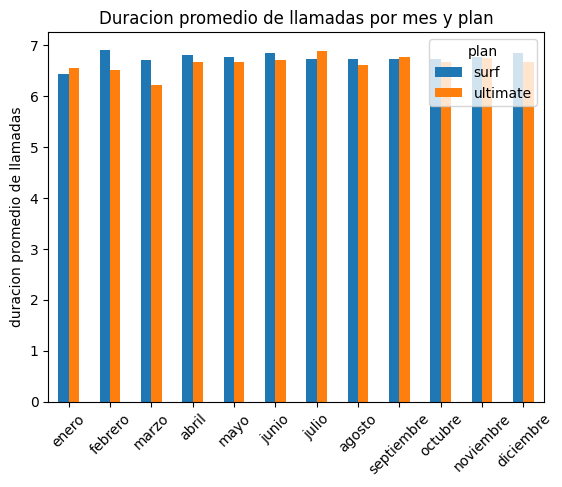

In [41]:
mins_plan_month = merged_calls.pivot_table(index='month', columns='plan', values='duration', aggfunc='mean')

mins_plan_month.index=["enero", "febrero", "marzo", "abril", "mayo","junio",
                      "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"]

mins_plan_month.plot(kind='bar',
                    ylabel= 'duracion promedio de llamadas',
                    rot= 45,
                    title= 'Duracion promedio de llamadas por mes y plan')

mins_plan_month


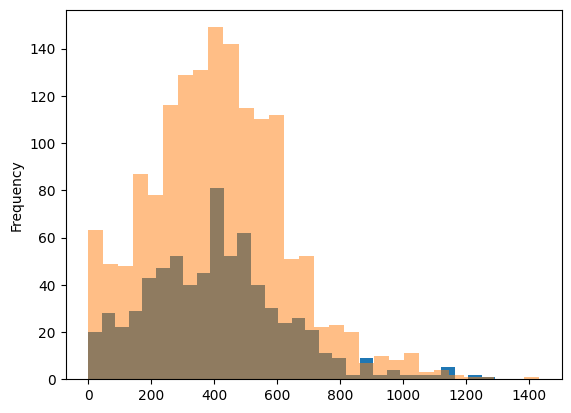

In [42]:
alphas=[1, 0.5]
for plan, alpha in zip (merged_df.plan.unique(), alphas):
    merged_df.query('plan == @plan').duration_minus.plot(kind = 'hist', alpha=alpha, bins=30)

<AxesSubplot:ylabel='Frequency'>

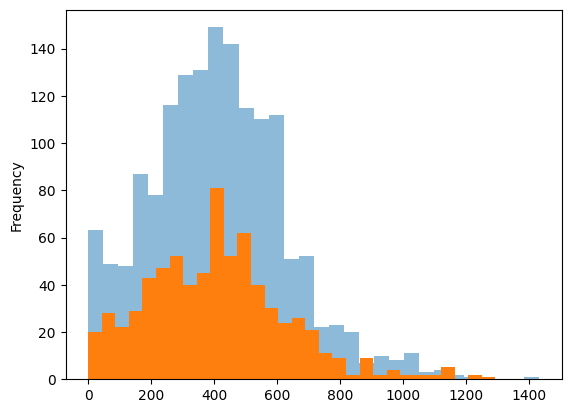

In [43]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
merged_df.query('plan == "surf"')['duration_minus'].plot(kind ='hist', alpha=0.5, bins=30)
merged_df.query('plan == "ultimate"')['duration_minus'].plot(kind='hist', bins=30)


[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [44]:
# Calcula la media y la varianza de la duración mensual de llamadas.
media_monthly_calls = merged_df['duration_minus'].mean()
varianza_monthly_calls = merged_df['duration_minus'].var()

print(f"la media de la duracion mensual de llamadas es: {media_monthly_calls}")
print(f"la varianza de la duracion mensual de llamadas es: {varianza_monthly_calls}")


la media de la duracion mensual de llamadas es: 411.4925863596103
la varianza de la duracion mensual de llamadas es: 48088.30262015758


<AxesSubplot:xlabel='plan', ylabel='duration_minus'>

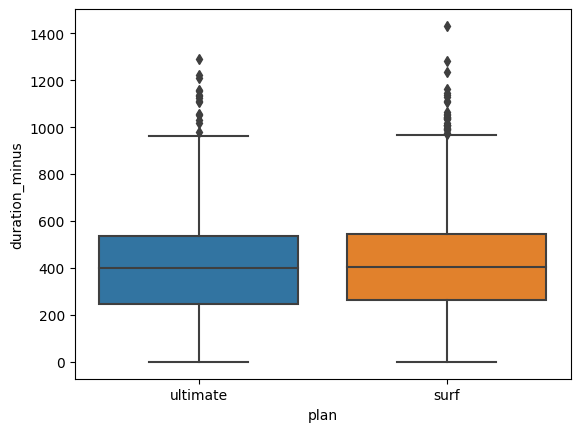

In [45]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
sns.boxplot(x='plan', y='duration_minus', data= merged_df)


[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

Mediante este diagrama de cajas podemos odservar que la distribucion de las llamabas entre ambas lineas es bastante similar, los usuarios al parecer se sienten comodos con ambas lineas a la hora de realizar llamadas.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>

Buena manera de mostrar los datos, se puede ver claramente las tendencias de cada uno de los planes gracias a las gráficas que has utilizado con las cuales podemos revisar aspectos diferentes de los planes
</div>


### Mensajes

In [46]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
merged_mss = df_messages.merge(df_users[['user_id', 'plan']], on='user_id', how= 'left')
merged_mss.head()


,id,user_id,message_date,year,month,day,plan
0,1000_125,1000,2018-12-27,2018,12,27,ultimate
1,1000_160,1000,2018-12-31,2018,12,31,ultimate
2,1000_223,1000,2018-12-31,2018,12,31,ultimate
3,1000_251,1000,2018-12-27,2018,12,27,ultimate
4,1000_255,1000,2018-12-26,2018,12,26,ultimate


In [47]:
merged_df

,user_id,month,call_count,mess_amnt,duration_minus,mb_used,plan,ingreso
0,1000,12,16,11.0,116.83,1901.47,ultimate,70.0000
1,1001,8,27,30.0,171.14,6919.15,surf,20.0000
2,1001,9,49,44.0,297.69,13314.82,surf,20.0000
3,1001,10,65,53.0,374.11,22330.49,surf,93.3949
4,1001,11,64,36.0,404.59,18504.30,surf,55.0430
...,...,...,...,...,...,...,...,...
2253,1498,12,39,0.0,324.77,23137.69,surf,101.3769
2254,1499,9,41,0.0,330.37,12984.76,surf,20.0000
2255,1499,10,53,0.0,363.28,19492.43,surf,64.9243
2256,1499,11,45,0.0,288.56,16813.83,surf,38.1383


<AxesSubplot:ylabel='Frequency'>

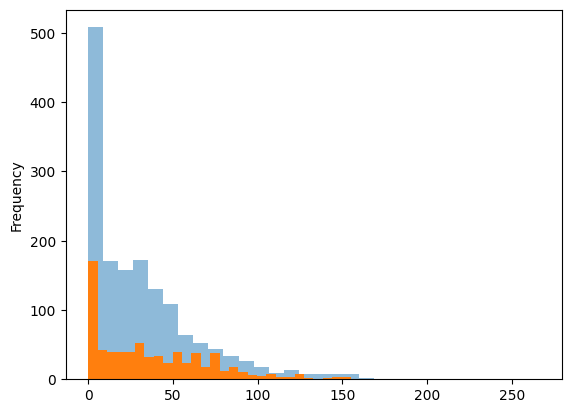

In [48]:
merged_df.query('plan =="surf"')['mess_amnt'].plot(kind ='hist', alpha=0.5, bins=30)
merged_df.query('plan =="ultimate"')['mess_amnt'].plot(kind ='hist', bins=30)

plan,surf,ultimate
enero,21,62
febrero,108,151
marzo,351,243
abril,870,463
mayo,1849,931
junio,2454,1379
julio,3271,1937
agosto,4662,2732
septiembre,5968,3259
octubre,8020,4181


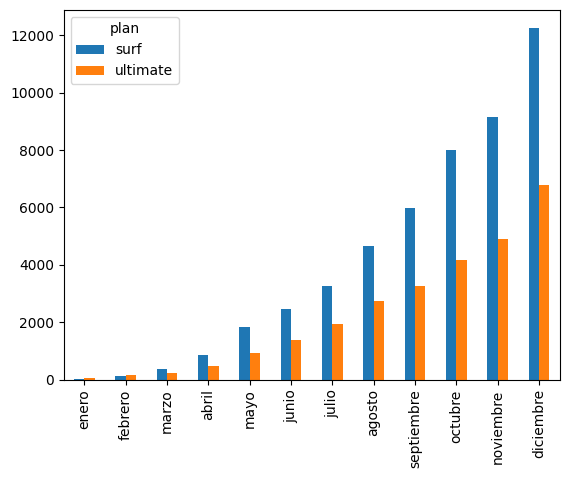

In [49]:
#compara el numero de mensajes que tienden a enviar cada mes los usuarios de cada plan
merged_mss_pivot = merged_mss.pivot_table(index='month', columns='plan', values='id', aggfunc='count')

merged_mss_pivot.index=["enero", "febrero", "marzo", "abril", "mayo", "junio",
                        "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"]

merged_mss_pivot.plot(kind='bar')

merged_mss_pivot


<AxesSubplot:xlabel='plan'>

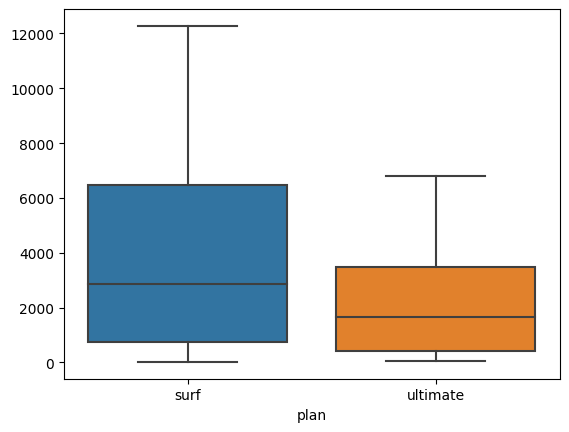

In [50]:
sns.boxplot(data=merged_mss_pivot)

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

Mediante esta distribucion podemos observar que en cuanto a los mensajes los usuarios eligieron la linea surf, danto asi como resultado un mayor indice de mensajes durante todos los meses del año, probablemente la mensajeria en esa linea telefonica brindaba un mejor servicio.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Buena manera de mostrar los datos de la misma manera que en `llamadas`, así se mantiene una constancia a lo largo del proyecto
</div>


### Internet

<AxesSubplot:ylabel='Frequency'>

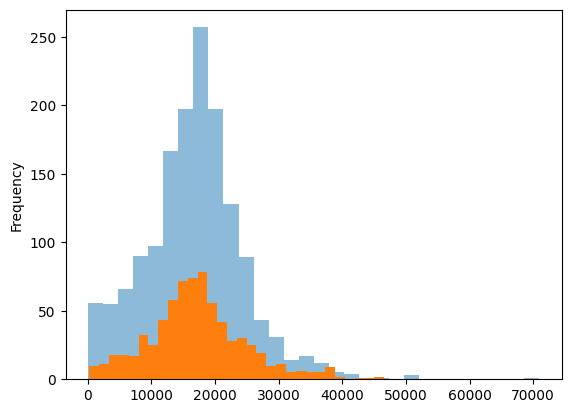

In [51]:
merged_df.query('plan == "surf"')['mb_used'].plot(kind ='hist', alpha=0.5, bins=30)
merged_df.query('plan == "ultimate"')['mb_used'].plot(kind ='hist', bins=30)

In [52]:
#compara la cantidad de trafico de internet consumido por usuarios por plan
df_internet_merge = df_internet.merge(df_users[['user_id', 'plan']], on='user_id', how='left')
df_internet_merge.head()

,id,user_id,session_date,mb_used,year,month,day,plan
0,1000_13,1000,2018-12-29,89.86,2018,12,29,ultimate
1,1000_204,1000,2018-12-31,0.00,2018,12,31,ultimate
2,1000_379,1000,2018-12-28,660.40,2018,12,28,ultimate
3,1000_413,1000,2018-12-26,270.99,2018,12,26,ultimate
4,1000_442,1000,2018-12-27,880.22,2018,12,27,ultimate


<AxesSubplot:>

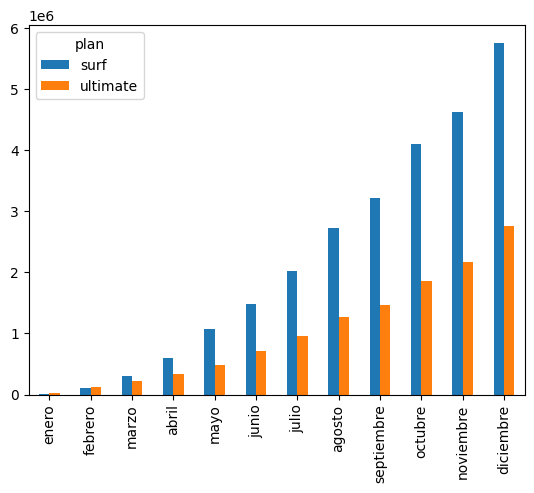

In [53]:
df_internet_merge_pivot = df_internet_merge.pivot_table(index='month', columns='plan', values='mb_used', aggfunc='sum')
df_internet_merge_pivot.index =["enero", "febrero", "marzo", "abril", "mayo", "junio",
                        "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"]

df_internet_merge_pivot.plot(kind='bar')

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

De igual manera podemos observar en esta grafica la influencia que tiene el plan surf en cuanto al uso de internet, podemos darnos cuenta que el trafico del internet tuvo un buen alcance durante todos los meses del año, superando asi al plan ultimate, podemos sacar una pequeña teoria de que una de las ventajas que pudo haber influenciado en este resultado pudo ser la velocidad en la que navegaban los usuarios, es decir la velocidad probablemente es mas veloz a la hora de navegar.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Gracias a estos analisis podemos crear nuevas estrategias para optimizar los planes y dar un mayor beneficio a cambio de mejores ingresos
</div>


## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

In [54]:
print('***** PARA EL PLAN SURF*****\n', merged_df.query('plan == "surf"')['ingreso'].describe(),'\n*****')
print('***** PARA EL PLAN ULTIMATE*****\n', merged_df.query('plan == "ultimate"')['ingreso'].describe(), '\n*****')

***** PARA EL PLAN SURF*****
 count    1545.000000
mean       58.171283
std        53.308069
min        20.000000
25%        20.000000
50%        38.765700
75%        79.942600
max       581.595900
Name: ingreso, dtype: float64 
*****
***** PARA EL PLAN ULTIMATE*****
 count    713.000000
mean      72.431102
std       11.921326
min       70.000000
25%       70.000000
50%       70.000000
75%       70.000000
max      186.167310
Name: ingreso, dtype: float64 
*****


[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

Mediante esta descripcion podemos observar relevancia que presenta el plan Surf con respecto al plan Ultimate. Al parecer la tarifa que genera mas ingresos es la del plan surf.


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Recomendaría acompañar los resultados con gráficas para mostrar las diferencias de una manera más clara
</div>


## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [55]:
merged_df.head()


,user_id,month,call_count,mess_amnt,duration_minus,mb_used,plan,ingreso
0,1000,12,16,11.0,116.83,1901.47,ultimate,70.0000
1,1001,8,27,30.0,171.14,6919.15,surf,20.0000
2,1001,9,49,44.0,297.69,13314.82,surf,20.0000
3,1001,10,65,53.0,374.11,22330.49,surf,93.3949
4,1001,11,64,36.0,404.59,18504.30,surf,55.0430


In [56]:
promedio_surf = merged_df.query('plan == "surf"')
promedio_surf
promedio_ultimate =  merged_df.query('plan == "ultimate"')
promedio_ultimate

,user_id,month,call_count,mess_amnt,duration_minus,mb_used,plan,ingreso
0,1000,12,16,11.0,116.83,1901.47,ultimate,70.00000
19,1006,11,2,15.0,9.32,2068.37,ultimate,70.00000
20,1006,12,9,139.0,54.79,32118.82,ultimate,84.83174
26,1008,10,71,21.0,450.21,17106.99,ultimate,70.00000
27,1008,11,63,37.0,422.81,23676.72,ultimate,70.00000
...,...,...,...,...,...,...,...,...
2223,1493,9,66,0.0,505.13,14991.17,ultimate,70.00000
2224,1493,10,66,0.0,424.25,16329.57,ultimate,70.00000
2225,1493,11,73,0.0,472.15,15630.78,ultimate,70.00000
2226,1493,12,65,0.0,446.28,15289.09,ultimate,70.00000


In [57]:
# Prueba las hipótesis
#ho = No hay diferencias entre los ingresos de los planes
#h1 = Los ingresos promedio de los planes son diferentes

alpha = 0.05
results = st.ttest_ind(promedio_surf['ingreso'], merged_df.query('plan =="ultimate"')['ingreso'], equal_var=False)

if results.pvalue < alpha:
    print(f'Rechazamos la hipotesis nula por lo tanto, las medias de income entre los planes son diferentes \n pvalue: {results.pvalue}')
else:
    print(f'No rechazamos la hipotesis nula \n pvalue: {results.pvalue}') 


Rechazamos la hipotesis nula por lo tanto, las medias de income entre los planes son diferentes 
 pvalue: 6.520533853548192e-23


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [58]:
# Prueba las hipótesis
merged_df_reg = merged_df.merge(df_users[['user_id', 'city']], on='user_id', how='left')
merged_df_reg.head()
merged_df_reg.city.value_counts()


New York-Newark-Jersey City, NY-NJ-PA MSA          371
Los Angeles-Long Beach-Anaheim, CA MSA             124
Chicago-Naperville-Elgin, IL-IN-WI MSA              89
Dallas-Fort Worth-Arlington, TX MSA                 88
Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA     80
                                                  ... 
Omaha-Council Bluffs, NE-IA MSA                      3
El Paso, TX MSA                                      2
Jacksonville, FL MSA                                 2
Raleigh-Cary, NC MSA                                 2
Cape Coral-Fort Myers, FL MSA                        1
Name: city, Length: 73, dtype: int64

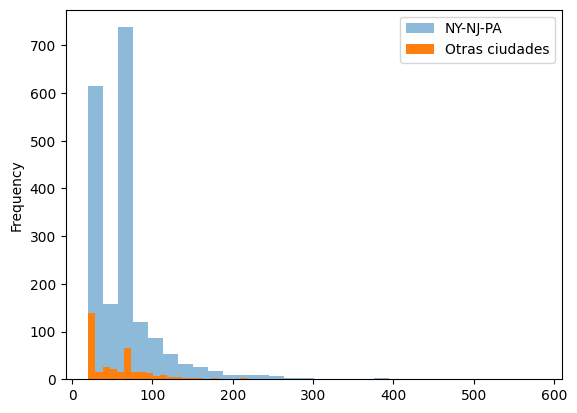

In [59]:
merged_df_reg.query('city != "New York-Newark-Jersey City, NY-NJ-PA MSA"')['ingreso'].plot(kind ='hist', bins=30,alpha=0.5)
merged_df_reg.query('city == "New York-Newark-Jersey City, NY-NJ-PA MSA"')['ingreso'].plot(kind ='hist', bins=30)


plt.legend(['NY-NJ-PA', 'Otras ciudades'])

In [60]:
#h0 = Los ingresos promedio de los usuarios de NY NJ son iguales a los de las otras regiones.
#h1 = Los ingresos promedio de los usuarios de NY NJ  son diferentes a los de las otras regiones

alpha=0.05

NYNJ_data = merged_df_reg[merged_df_reg['city'] == "New York-Newark-Jersey City, NY-NJ-PA MSA"]['ingreso']
other_data = merged_df_reg[merged_df_reg['city'] != "New York-Newark-Jersey City, NY-NJ-PA MSA"]['ingreso']

results = st.ttest_ind(NYNJ_data, other_data, equal_var=False)

if results.pvalue < alpha:
    print(f'Rechazamos la hipotesis nula por lo tanto, los ingresos promedio de los usuarios de NY NJ son diferentes a los de las otras regiones \n pvalue: {results.pvalue}')

else:
    print(f'No rechazamos la hipotesis nula \n pvalue: {results.pvalue}')
    

Rechazamos la hipotesis nula por lo tanto, los ingresos promedio de los usuarios de NY NJ son diferentes a los de las otras regiones 
 pvalue: 0.014070859219080691


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!

La aplicación de las pruebas de hipotesis me parece acertada, seleccionando los datos y valores correctos
</div>


## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]

En conclusion despues de hacer ciertos analisis con respecto a los planes que generan mas ingresos, se logran encontrar ciertos inconvenientes a la hora de abordar el codigo, en este caso en las columnas con tipos de datos de manera incorrecta, dando asi la necesidad de convertirlos, unos a datos numeros y en otras ocaciones a tipo string(object), utilizando diferentes metodos para asi lograr obtener una mejor claridad con respecto a los datos, y asi mismo dando como resultado un codigo limpio. De esta manera se procede a investigar ambos planes y los meses del año donde hubo mayor y menor frecuencia en los diferentes ambitos del servicio, los cuales serian, la mensajeria, las llamadas, el internet y el uso de MB. En este caso se hace el analisis para ambos planes y se logra deducir que el plan que genera mas ingresos fue el plan Surf, donde mediante algunas graficas pudimos observar que soprepaso al plan ultimate en ciertas categorias todos los meses del año.

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo al desarrollar este proyecto, las observaciones que has hecho a lo largo del mismo han servido para tomar acción en los pasos posteriores, terminando en resultados positivos.

Este es un proyecto que nos adentra mucho en los analisis que se hacen recurrentemente en las compañías donde se obtiene información para tomar decisiones sobre el negocio que impactan directamente los ingresos, lo has hecho bastante bien!

Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!    
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
    
</div>

<div class="alert alert-block alert-warning">
<b>Aspectos que pueden mejorar del proyecto</b> <a class="tocSkip"></a><br />

- Recomendaría usar las mismas graficas en todas las secciones, de esta manera se puede mantener una consistencia en las comparaciones de los distintos aspectos de los planes

</div>
